In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix,classification_report

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df.sample(7)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
231,232.0,14757.0,2736.0,Unemployed,21.0,Married,3.0,661.0,4.0,0.55,4784.0,5974.0,28898.0,48.0,Home,Urban,Not Graduate,Male,MNC,No
822,NaN,12789.0,6704.0,Salaried,31.0,Married,0.0,792.0,2.0,0.27,11528.0,40438.0,27199.0,84.0,Education,Urban,Not Graduate,Female,Unemployed,Yes
126,127.0,17707.0,8592.0,Self-employed,NaN,Married,3.0,738.0,0.0,0.33,3319.0,11929.0,24246.0,24.0,Business,Urban,Graduate,Male,Government,Yes
257,258.0,3060.0,9175.0,Self-employed,34.0,Single,2.0,675.0,3.0,0.17,7829.0,17732.0,4691.0,36.0,Education,Semiurban,Not Graduate,Male,MNC,Yes
617,618.0,16388.0,7473.0,Contract,22.0,Single,0.0,695.0,3.0,NaN,12482.0,40159.0,28956.0,36.0,Car,Semiurban,Not Graduate,NaN,Government,Yes
42,43.0,14206.0,2681.0,Contract,45.0,Married,0.0,703.0,0.0,0.55,18848.0,6302.0,34529.0,48.0,Business,Semiurban,Not Graduate,Female,Private,No
694,695.0,8288.0,1440.0,Self-employed,35.0,Married,0.0,603.0,0.0,0.11,7130.0,22185.0,9520.0,12.0,Car,Rural,Graduate,Female,Unemployed,No


In [3]:
print("infromation about data :")
df.info()

infromation about data :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-nul

In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [5]:
print("Checking for null values : ")
df.isnull().sum()

Checking for null values : 


Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

### Handle Null-Values

In [6]:
numerical_features = df.select_dtypes(include = "number").columns 
categorical_features = df.select_dtypes(include = "object").columns

In [7]:
print(categorical_features)
print(numerical_features)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [8]:
numeric_imputer = SimpleImputer(strategy = "mean")
df[numerical_features] = numeric_imputer.fit_transform(df[numerical_features])
categorical_imputer = SimpleImputer(strategy = "most_frequent")
df[categorical_features] = categorical_imputer.fit_transform(df[categorical_features])

In [9]:
print("Checking for null values : ")
df.isnull().sum()

Checking for null values : 


Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### EDA

[Text(0, 0, '702'), Text(0, 0, '298')]

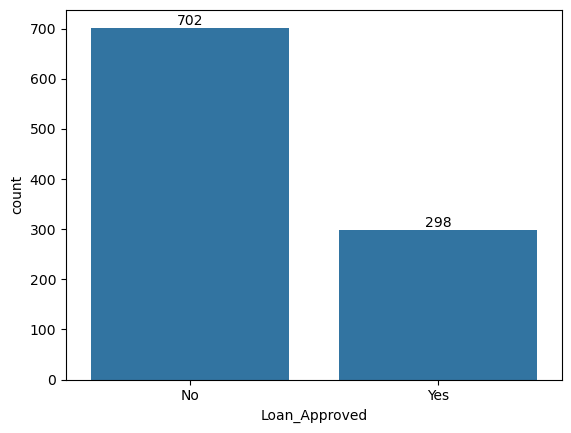

In [10]:
ax = sns.countplot( x = df['Loan_Approved'])
ax.bar_label(ax.containers[0])

[Text(0, 0, '379'), Text(0, 0, '621')]

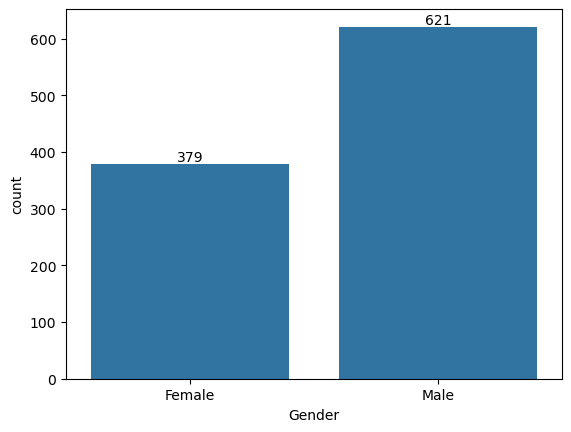

In [11]:
ax = sns.countplot(data = df , x = 'Gender')
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

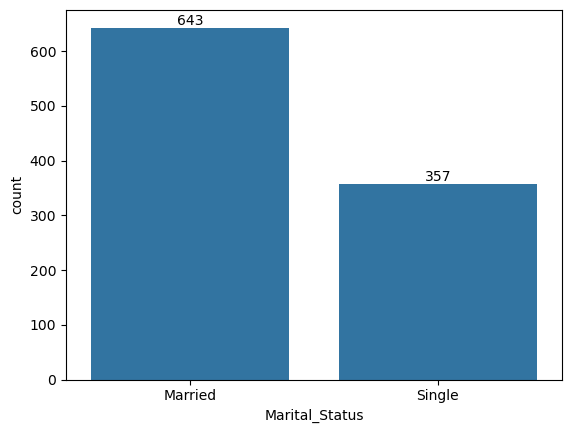

In [12]:
ax = sns.countplot(data = df , x = 'Marital_Status')
ax.bar_label(ax.containers[0])

[Text(0, 0, '278'), Text(0, 0, '722')]

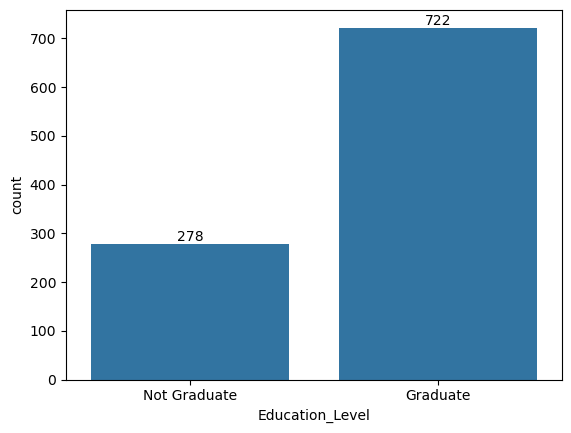

In [13]:
ax = sns.countplot(data = df , x = 'Education_Level')
ax.bar_label(ax.containers[0])

<Axes: xlabel='Credit_Score', ylabel='Loan_Amount'>

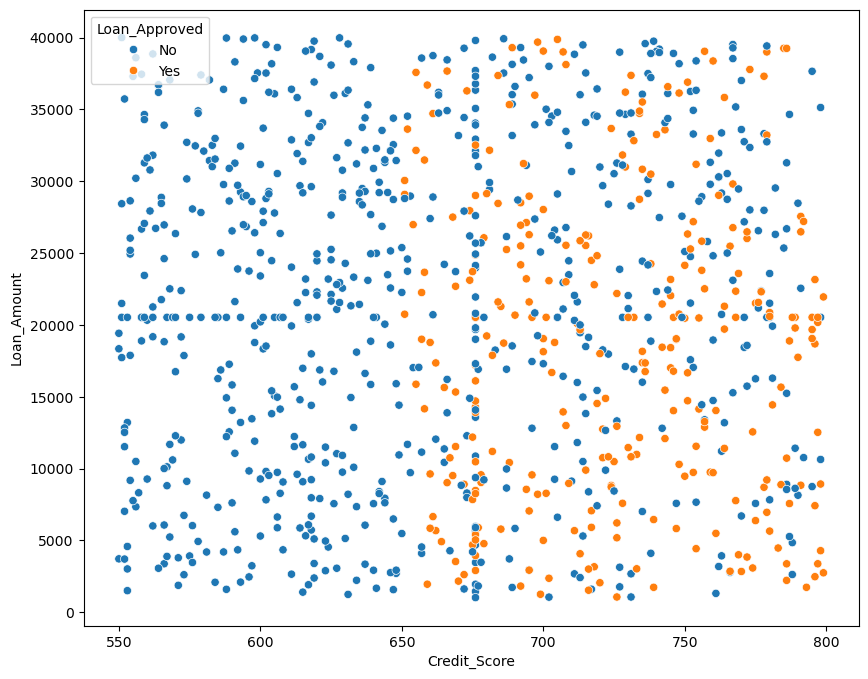

In [14]:
plt.figure(figsize = (10,8))
sns.scatterplot(data =df ,x = 'Credit_Score',y ='Loan_Amount',hue = 'Loan_Approved')

<Axes: xlabel='Credit_Score', ylabel='Count'>

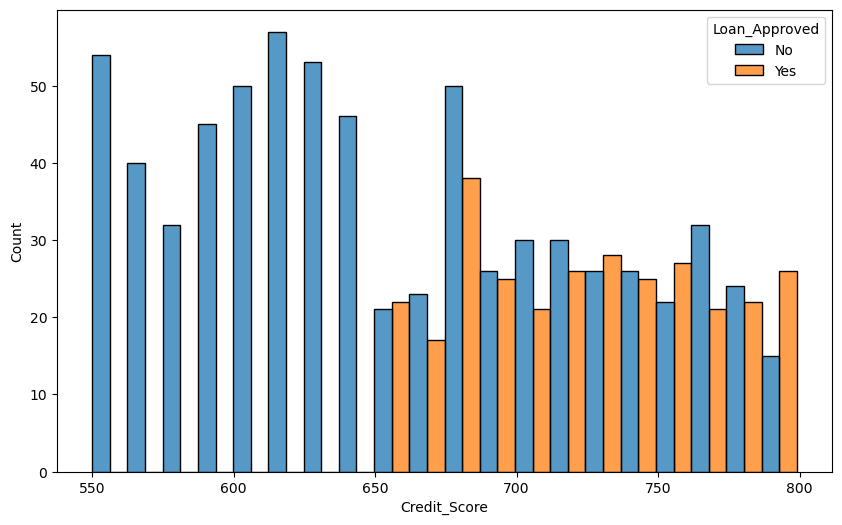

In [15]:
plt.figure(figsize = (10,6))
sns.histplot(data=df,x='Credit_Score',hue = "Loan_Approved",bins =20,multiple = 'dodge')

<Axes: xlabel='Applicant_Income', ylabel='Count'>

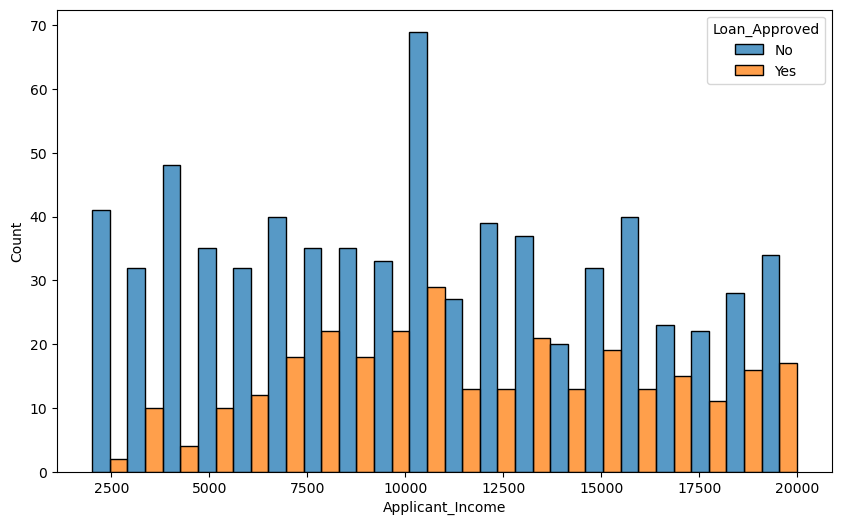

In [16]:
plt.figure(figsize = (10,6))
sns.histplot(data =df , x = "Applicant_Income",hue="Loan_Approved",bins = 20,multiple = 'dodge')

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

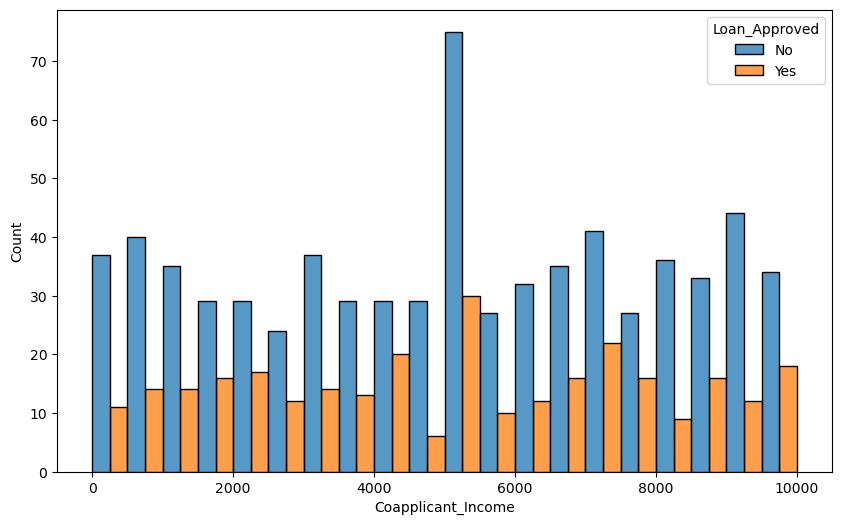

In [17]:
plt.figure(figsize = (10,6))
sns.histplot(data =df , x = "Coapplicant_Income",hue="Loan_Approved",bins =20,multiple = 'dodge')

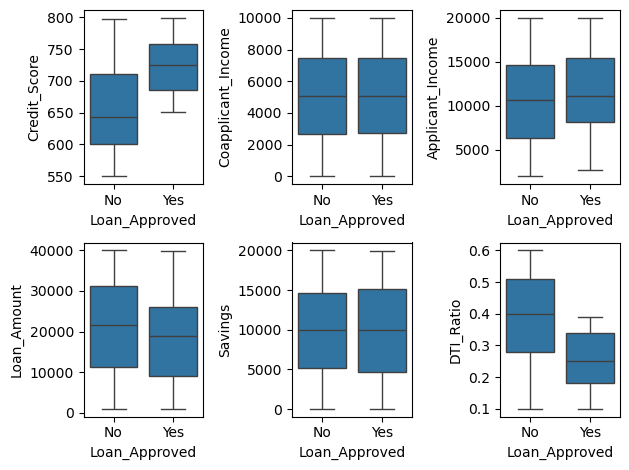

In [18]:
fig ,axes = plt.subplots(2,3)
sns.boxplot(ax = axes[0,0],data =df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[0,1],data =df,x = "Loan_Approved",y = "Coapplicant_Income")
sns.boxplot(ax = axes[0,2],data =df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[1,0],data =df,x = "Loan_Approved",y = "Loan_Amount")
sns.boxplot(ax = axes[1,1],data =df,x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = axes[1,2],data =df,x = "Loan_Approved",y = "DTI_Ratio")
plt.tight_layout()

### Encoding

In [19]:
df.select_dtypes(include = 'object').columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [20]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])

In [21]:
ohe = OneHotEncoder(drop = 'first', sparse_output=False,  handle_unknown='ignore')
cols = ['Marital_Status', 'Loan_Purpose', 'Property_Area','Employment_Status', 'Gender', 'Employer_Category' ]
encoder = ohe.fit_transform(df[cols])

In [22]:
encoded = pd.DataFrame(encoder,columns = ohe.get_feature_names_out(cols),index = df.index)

In [23]:
df = pd.concat([df.drop(columns = cols),encoded],axis =1)

In [24]:
df.drop(["Applicant_ID"],axis = 1,inplace = True)

In [25]:
df.shape

(1000, 28)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [27]:
df.sample(7)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
346,5343.0,5346.0,32.0,0.0,780.0,1.0,0.347263,18928.000000,20567.0,23574.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
219,4869.0,3564.0,57.0,3.0,719.0,1.0,0.170000,4368.000000,45213.0,34522.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
13,2769.0,7368.0,26.0,0.0,767.0,3.0,0.180000,14260.000000,39697.0,23102.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
445,6491.0,8032.0,30.0,1.0,658.0,0.0,0.240000,19142.000000,25544.0,14156.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
372,11540.0,6446.0,54.0,1.0,611.0,0.0,0.460000,9940.452632,45785.0,24016.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
719,3605.0,5243.0,30.0,0.0,615.0,0.0,0.330000,8907.000000,33642.0,9078.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
712,3761.0,5445.0,48.0,2.0,648.0,4.0,0.347263,17801.000000,46008.0,15901.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Save to CSV

In [29]:
df.to_csv("processed_data.csv", index=False)

### correlation matrix

In [30]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()


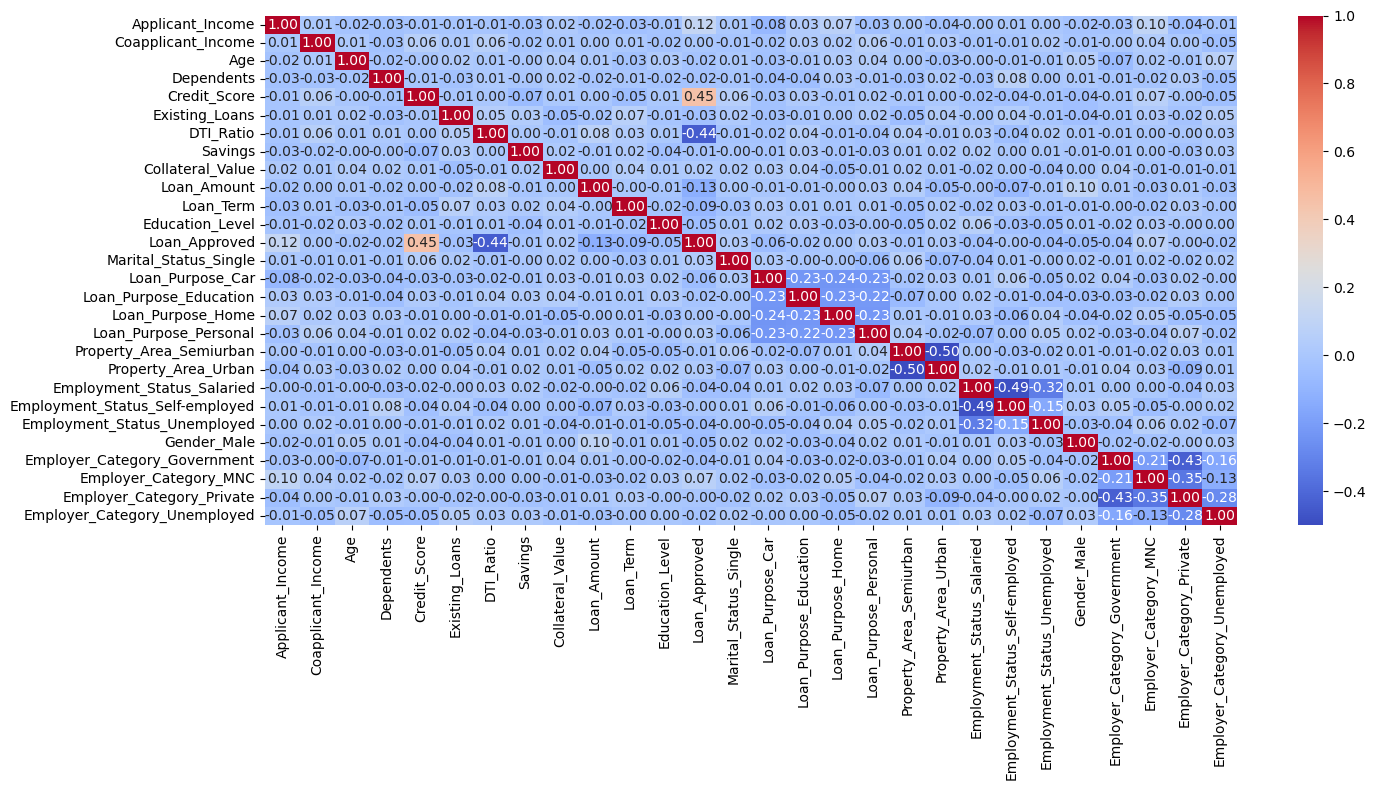

In [31]:
plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.tight_layout()

### Train-Test-Split & Feature Scaling

In [34]:
X = df.drop("Loan_Approved",axis =1)
y = df["Loan_Approved"]

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [36]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.fit_transform(X_test)

### Feature Engineering

In [37]:
#Tranform Feature
df["Credit_Score_sq"] = df['Credit_Score']**2
df["DTI_Ratio_sq"] = df['DTI_Ratio']**2
X = df.drop(["Loan_Approved","Credit_Score","DTI_Ratio"],axis =1)
y = df["Loan_Approved"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training & Evaluation 

In [38]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train_scaled, y_train)

y_pred = ada_model.predict(X_test_scaled)

print("Precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("confusion matrix :\n ",confusion_matrix(y_test,y_pred))

Precision :  0.8
Recall :  0.9180327868852459
f1_score :  0.8549618320610687
Accuracy :  0.905
confusion matrix :
  [[125  14]
 [  5  56]]


### Save The Model

In [40]:
import pickle

# save model
pickle.dump(ada_model, open("loan_model.pkl", "wb"))

# save scaler if you used scaling
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [41]:
print(X.columns)

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount',
       'Loan_Term', 'Education_Level', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Gender_Male', 'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'Credit_Score_sq', 'DTI_Ratio_sq'],
      dtype='object')
